# Climate Change Sentiment AnalysisThis notebook analyzes public opinions about climate change using NASA Facebook comments.It includes:- Data loading- Data cleaning- Exploratory Data Analysis (EDA)- Sentiment analysis- Machine learning model

## 1. Import Libraries

In [1]:
!pip install textblob

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


## 2. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv("C:\\Users\\Divyanshu\\OneDrive\\Desktop\\Climate Change Modelling Project\\climate_nasa.csv")

# Display first rows
df.head()


,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


## 3. Dataset Overview

In [4]:
# Dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


In [5]:
# Statistical summary
df.describe()


,likesCount,commentsCount
count,522.000000,244.000000
mean,4.720307,8.696721
std,12.053556,12.266176
min,0.000000,1.000000
25%,0.000000,2.000000
50%,1.000000,5.000000
75%,4.000000,10.000000
max,126.000000,93.000000


## 4. Missing Values Analysis

In [6]:
# Check missing values
df.isnull().sum()


date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64

## 5. Feature Engineering

In [7]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Convert text to string
df['text'] = df['text'].astype(str)

# Create comment length feature
df['text_length'] = df['text'].apply(len)

df.head()


,date,likesCount,profileName,commentsCount,text,year,month,day,text_length
0,2022-09-07 17:12:32+00:00,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...,2022,9,7,173
1,2022-09-08 14:51:13+00:00,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...,2022,9,8,51
2,2022-09-07 17:19:41+00:00,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...,2022,9,7,108
3,2022-09-08 00:51:30+00:00,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...,2022,9,8,94
4,2022-09-07 19:06:20+00:00,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart...",2022,9,7,128


## 6. Likes Distribution

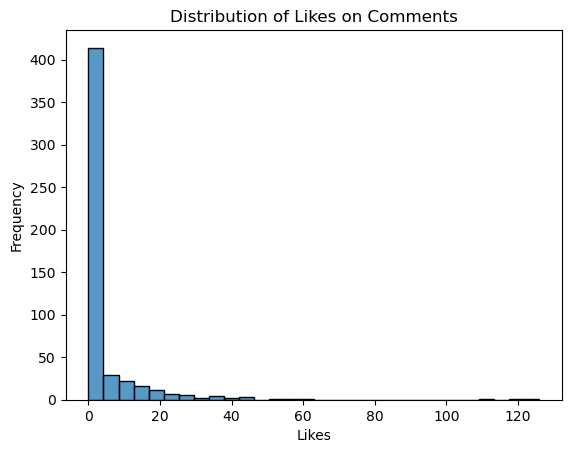

In [8]:
plt.figure()
sns.histplot(df['likesCount'], bins=30)

plt.title('Distribution of Likes on Comments')
plt.xlabel('Likes')
plt.ylabel('Frequency')

plt.show()


## 7. Replies Distribution

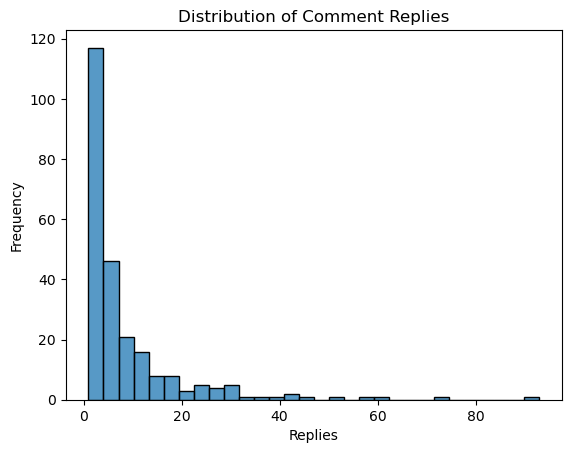

In [9]:
plt.figure()
sns.histplot(df['commentsCount'], bins=30)

plt.title('Distribution of Comment Replies')
plt.xlabel('Replies')
plt.ylabel('Frequency')

plt.show()


## 8. Comment Length Analysis

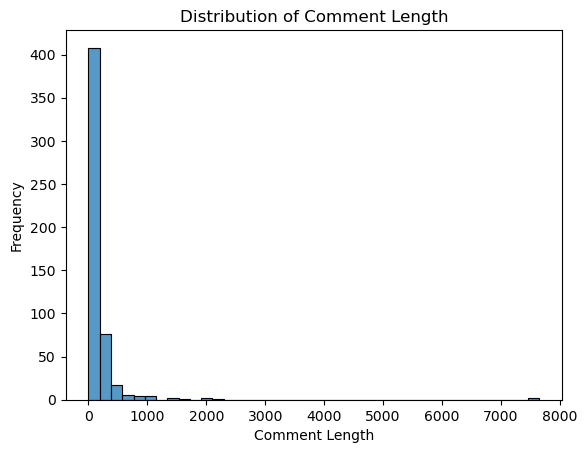

In [10]:
plt.figure()
sns.histplot(df['text_length'], bins=40)

plt.title('Distribution of Comment Length')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')

plt.show()


## 9. Likes vs Replies

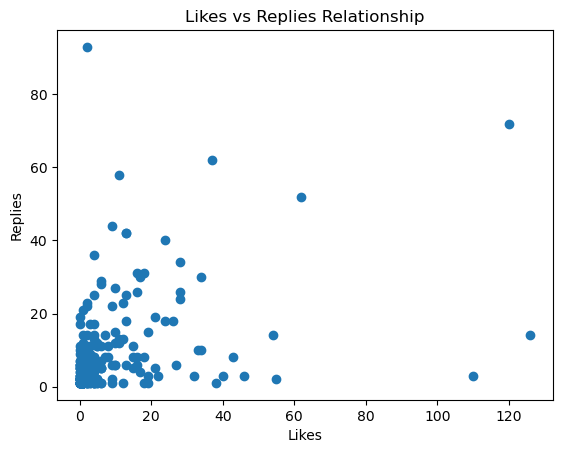

In [11]:
plt.figure()
plt.scatter(df['likesCount'], df['commentsCount'])

plt.title('Likes vs Replies Relationship')
plt.xlabel('Likes')
plt.ylabel('Replies')

plt.show()


## 10. Sentiment Analysis

In [12]:
# Calculate sentiment score
df['sentiment_score'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Sentiment classification function
def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply classification
df['sentiment_type'] = df['sentiment_score'].apply(classify_sentiment)

df[['text','sentiment_score','sentiment_type']].head()


,text,sentiment_score,sentiment_type
0,Neat comparison I have not heard it before.\n ...,0.000000,Neutral
1,An excellent way to visualise the invisible! T...,0.600000,Positive
2,Does the CO2/ghg in the troposphere affect the...,0.000000,Neutral
3,excellent post! I defo feel the difference - o...,0.053571,Positive
4,"Yes, and carbon dioxide does not harm the Eart...",-0.375000,Negative


## 11. Sentiment Distribution

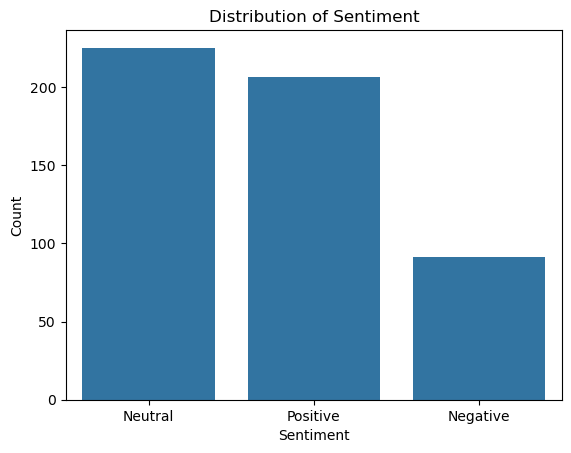

In [13]:
sns.countplot(x='sentiment_type', data=df)

plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()


## 12. Engagement by Sentiment

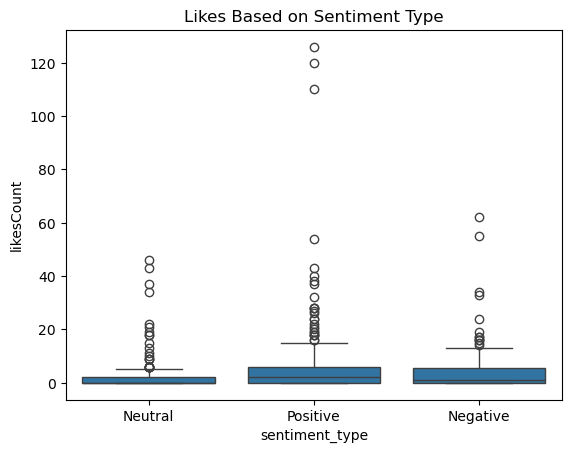

In [14]:
sns.boxplot(x='sentiment_type', y='likesCount', data=df)

plt.title('Likes Based on Sentiment Type')

plt.show()


## 13. Correlation Analysis

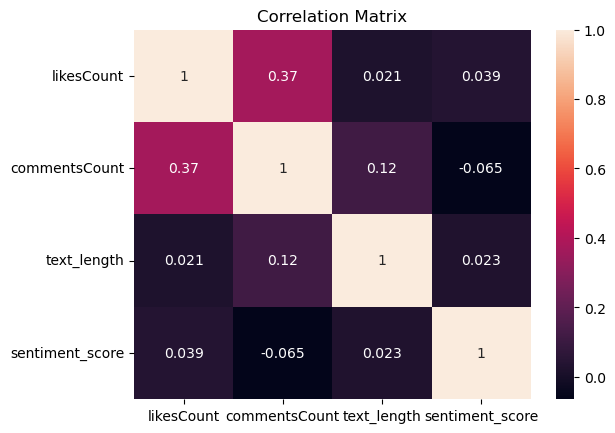

In [15]:
corr = df[['likesCount','commentsCount','text_length','sentiment_score']].corr()

plt.figure()
sns.heatmap(corr, annot=True)

plt.title('Correlation Matrix')

plt.show()


## 14. Comments by Year

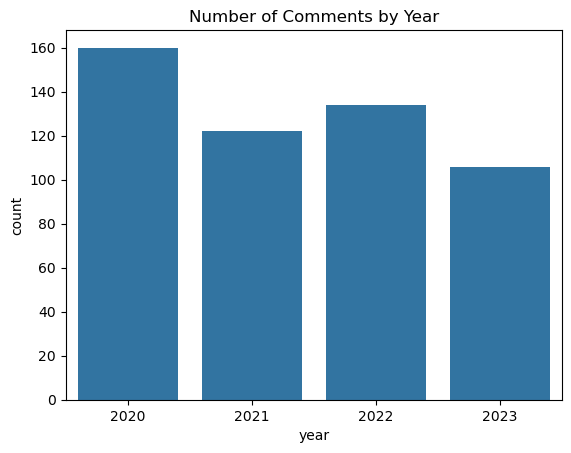

In [16]:
sns.countplot(x='year', data=df)

plt.title('Number of Comments by Year')

plt.show()


## 15. Machine Learning Model

In [17]:
# Define features and target
X = df[['text_length','sentiment_score']]
y = df['likesCount']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)


Mean Squared Error: 160.82959856001716
R2 Score: 0.10486487042350623


## 16. Actual vs Predicted Likes

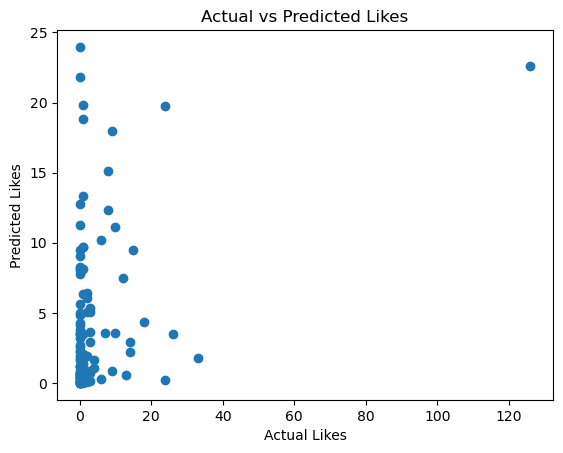

In [18]:
plt.figure()
plt.scatter(y_test, predictions)

plt.title('Actual vs Predicted Likes')
plt.xlabel('Actual Likes')
plt.ylabel('Predicted Likes')

plt.show()


## 17. Conclusion. Most comments show neutral sentiment.2. Positive comments often receive slightly higher engagement.3. Comment length has a small influence on engagement.4. Sentiment analysis helps understand public perception of climate change.